In [1]:
import os

DATASET_PATH = r"C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG"


print("🔍 Checking Dataset Path...")
print(os.listdir(DATASET_PATH)[:5])

🔍 Checking Dataset Path...
['BraTS19_2013_0_1', 'BraTS19_2013_15_1', 'BraTS19_2013_16_1', 'BraTS19_2013_1_1', 'BraTS19_2013_24_1']


In [2]:
from torch.utils.data import Dataset, DataLoader
import os, glob
import torch
import numpy as np
import nibabel as nib
import torch.nn.functional as F
from torchvision import transforms

class BraTSDataset(Dataset):
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.modalities = ["flair", "t1", "t1ce", "t2"]

        all_patients = sorted(os.listdir(dataset_path))
        self.patients = []

        for patient in all_patients:
            patient_path = os.path.join(dataset_path, patient)
            try:
                # Try to load one slice to validate
                _ = [self.load_nii(patient_path, mod) for mod in self.modalities]
                _ = self.load_nii(patient_path, "seg")
                self.patients.append(patient)
            except:
                print(f"⚠️ Skipping {patient} in init due to missing files")

    def __len__(self):
        return len(self.patients)

    def load_nii(self, patient_folder, modality):
        possible_files = glob.glob(os.path.join(patient_folder, f"*{modality}*.nii*"))

        if not possible_files and modality == "t1":
            possible_files = glob.glob(os.path.join(patient_folder, f"*ROI*{modality}*.nii*"))

        if not possible_files:
            raise FileNotFoundError(f"❌ No file found for modality '{modality}' in {patient_folder}")

        possible_files.sort(key=lambda x: x.endswith(".gz"), reverse=True)
        file_path = possible_files[0]

        print(f"✅ Loading: {file_path}")
        return nib.load(file_path).get_fdata()

    def __getitem__(self, idx):
        patient = self.patients[idx]
        patient_path = os.path.join(self.dataset_path, patient)

        try:
            images = [self.load_nii(patient_path, mod) for mod in self.modalities]
            images = np.stack(images, axis=0)

            mask = self.load_nii(patient_path, "seg")
            slice_idx = mask.shape[-1] // 2
            image = images[:, :, :, slice_idx]
            mask = mask[:, :, slice_idx]

            image_tensor = torch.tensor(image, dtype=torch.float32)
            mask_tensor = torch.tensor(mask, dtype=torch.long)

            image_tensor = F.interpolate(image_tensor.unsqueeze(0), size=(224, 224), mode="bilinear", align_corners=False).squeeze(0)
            mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0).float()
            mask_tensor = F.interpolate(mask_tensor, size=(224, 224), mode="nearest").squeeze(0).squeeze(0).long()

            print(f"✅ Loaded {patient}: Image {image_tensor.shape}, Mask {mask_tensor.shape}")
            return image_tensor, mask_tensor

        except FileNotFoundError as e:
            print(f"⚠️ Skipping {patient} due to missing files: {e}")
            return None

# ➕ Custom collate_fn to skip Nones in batches
def skip_none_collate(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        # Return dummy tensors so training doesn't crash
        return torch.empty(0), torch.empty(0, dtype=torch.long)
    return torch.utils.data.dataloader.default_collate(batch)

In [3]:
import glob
import torch.nn.functional as F

# Load Dataset
train_dataset = BraTSDataset(DATASET_PATH)

valid_samples = [d for d in train_dataset if d is not None]


if len(valid_samples) == 0:
    raise ValueError("❌ No valid samples found. Check dataset paths and file integrity.")


#train_loader = DataLoader(valid_samples, batch_size=2, shuffle=True, num_workers=0)
train_loader = DataLoader(valid_samples, batch_size=4, shuffle=True, collate_fn=skip_none_collate, num_workers=0)
print(f"✅ Loaded {len(train_loader.dataset)} valid patients from BraTS 2019.")

✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_2013_0_1\BraTS19_2013_0_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_2013_0_1\BraTS19_2013_0_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_2013_0_1\BraTS19_2013_0_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_2013_0_1\BraTS19_2013_0_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_2013_0_1\BraTS19_2013_0_1_seg.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\br

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from timm.models.swin_transformer import swin_tiny_patch4_window7_224 as SwinTransformer


class MultiScaleAttentionFusion(nn.Module):
    def __init__(self, in_channels):
        super(MultiScaleAttentionFusion, self).__init__()

        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, in_channels // 4, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 4, in_channels, 1, bias=False),
            nn.Sigmoid()
        )

        self.spatial_attn = nn.Sequential(
            nn.Conv2d(in_channels, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        c_attn = self.channel_attn(x)
        x = x * c_attn
        s_attn = self.spatial_attn(x)
        x = x * s_attn
        return x


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(UpBlock, self).__init__()
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
        )
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class SwinUNet(nn.Module):
    def __init__(self, img_size=224, in_channels=4, out_channels=4):
        super(SwinUNet, self).__init__()

        self.swin = SwinTransformer(pretrained=True)
        self.swin.head = nn.Identity()
        self.swin.patch_embed.proj = nn.Conv2d(in_channels, 96, kernel_size=4, stride=4, padding=0)

        self.attn1 = MultiScaleAttentionFusion(768)
        self.attn2 = MultiScaleAttentionFusion(384)
        self.attn3 = MultiScaleAttentionFusion(192)
        self.attn4 = MultiScaleAttentionFusion(96)

        self.up1 = UpBlock(768, 384, 384)
        self.up2 = UpBlock(384, 192, 192)
        self.up3 = UpBlock(192, 96, 96)
        self.up4 = nn.Sequential(
            nn.ConvTranspose2d(96, out_channels, kernel_size=2, stride=2)
        )

        # Deep supervision outputs
        self.aux_out1 = nn.Conv2d(384, out_channels, kernel_size=1)
        self.aux_out2 = nn.Conv2d(192, out_channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape

        x = self.swin.patch_embed(x)
        x = self.swin.patch_embed.norm(x)
        x = self.swin.layers[0](x)
        x1 = x.permute(0, 3, 1, 2)
        x = self.swin.layers[1](x)
        x2 = x.permute(0, 3, 1, 2)
        x = self.swin.layers[2](x)
        x3 = x.permute(0, 3, 1, 2)
        x = self.swin.layers[3](x)
        x4 = x.permute(0, 3, 1, 2)

        # Apply attention to skip features
        x1 = self.attn4(x1)
        x2 = self.attn3(x2)
        x3 = self.attn2(x3)
        x4 = self.attn1(x4)

        # Decoder with skip connections
        x = self.up1(x4, x3)
        aux1 = self.aux_out1(x)
        x = self.up2(x, x2)
        aux2 = self.aux_out2(x)
        x = self.up3(x, x1)
        x = self.up4(x)

        return x, aux1, aux2


# Loss Functions
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1.):
        super(SoftDiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # Resize target if shape mismatch
        if pred.shape[2:] != target.shape[1:]:
            target = F.interpolate(target.unsqueeze(1).float(), size=pred.shape[2:], mode="nearest").squeeze(1).long()

        # Assert class values are within range
        assert target.max() < pred.shape[1], f"Target has class {target.max().item()} >= num_classes {pred.shape[1]}"

        pred = torch.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = (pred * target_one_hot).sum(dim=dims)
        union = pred.sum(dim=dims) + target_one_hot.sum(dim=dims)
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


import torch.nn.functional as F

def combined_loss(preds, target):
    main_pred, aux1, aux2 = preds

    # Resize target to match the main_pred size (112x112)
    target_resized = F.interpolate(target.unsqueeze(1).float(), size=main_pred.shape[2:], mode="nearest").squeeze(1).long()

    # Debugging: Ensure target values are within the expected range
    assert torch.min(target_resized) >= 0 and torch.max(target_resized) < 4, "Target values must be in the range [0, 3]"
    print(f"Resized target min/max: {torch.min(target_resized)} / {torch.max(target_resized)}")
    
    # Dice + CrossEntropy for main prediction
    dice_loss = SoftDiceLoss()(main_pred, target_resized)
    ce_loss = nn.CrossEntropyLoss(
        weight=torch.tensor([0.1, 1.0, 1.0, 3.0]).to(main_pred.device)
    )(main_pred, target_resized)

    # Resize target to match aux1 and aux2 sizes
    target_aux1 = F.interpolate(target.unsqueeze(1).float(), size=aux1.shape[2:], mode="nearest").squeeze(1).long()
    target_aux2 = F.interpolate(target.unsqueeze(1).float(), size=aux2.shape[2:], mode="nearest").squeeze(1).long()

    # Auxiliary losses
    aux1_loss = nn.CrossEntropyLoss()(aux1, target_aux1)
    aux2_loss = nn.CrossEntropyLoss()(aux2, target_aux2)

    # Total loss: Weighted sum
    total_loss = dice_loss + ce_loss + 0.5 * aux1_loss + 0.5 * aux2_loss
    return total_loss



# Test
if __name__ == "__main__":
    device = "cpu"
    model = SwinUNet().to(device)
    dummy_input = torch.randn(2, 4, 224, 224).to(device)
    outputs = model(dummy_input)
    print("✅ Refactored Swin-UNet Forward Pass Successful! Output shape:", outputs[0].shape)

c:\Users\Dell\Desktop\Group_4_sem_6_AIML\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Refactored Swin-UNet Forward Pass Successful! Output shape: torch.Size([2, 4, 112, 112])


In [5]:
model = SwinUNet().to(device)
model.load_state_dict(torch.load(r"C:\Users\Dell\Desktop\Group_4_sem_6_AIML\saved model\2019_combined_loss_finetuned_hgg.pth"))
print("✅ Loaded pretrained weights from 2019_hgg dataset")

✅ Loaded pretrained weights from 2019_hgg dataset


In [7]:
import torch.optim as optim

In [8]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Initialize lists to store loss and accuracy
epoch_losses = []
epoch_accuracies = []

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_pixels = 0
    total_pixels = 0
    valid_batches = 0

    for batch in train_loader:
        if batch is None:
            print("⚠️ Skipping an invalid batch.")
            continue

        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        if targets.max() >= 4:
            targets = torch.clamp(targets, 0, 3)

        optimizer.zero_grad()
        outputs = model(inputs)

        # Resize outputs
        main_pred, aux1, aux2 = outputs
        main_pred = F.interpolate(main_pred, size=(224, 224), mode='bilinear', align_corners=False)
        aux1 = F.interpolate(aux1, size=(224, 224), mode='bilinear', align_corners=False)
        aux2 = F.interpolate(aux2, size=(224, 224), mode='bilinear', align_corners=False)

        print(f"Output shape: {main_pred.shape}, Target shape: {targets.shape}, Max target value: {targets.max()}")

        # Compute the loss
        loss = combined_loss([main_pred, aux1, aux2], targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        valid_batches += 1

        # Accuracy: compare argmax of predictions to targets
        pred_class = torch.argmax(main_pred, dim=1)
        correct_pixels += (pred_class == targets).sum().item()
        total_pixels += targets.numel()

    if valid_batches > 0:
        avg_loss = running_loss / valid_batches
        accuracy = correct_pixels / total_pixels
        epoch_losses.append(avg_loss)
        epoch_accuracies.append(accuracy)

        print(f"✅ Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy*100:.2f}%")
    else:
        print(f"❌ No valid batches in epoch {epoch+1}!")

# After training, plot loss and accuracy on one graph
def plot_loss_accuracy(losses, accuracies):
    epochs = range(1, len(losses) + 1)
    fig, ax1 = plt.subplots(figsize=(8, 6))

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss", color="red")
    ax1.plot(epochs, losses, color="red", label="Loss")
    ax1.tick_params(axis='y', labelcolor="red")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy", color="blue")
    ax2.plot(epochs, accuracies, color="blue", label="Accuracy")
    ax2.tick_params(axis='y', labelcolor="blue")

    plt.title("Training Loss and Accuracy")
    fig.tight_layout()
    plt.grid(True)
    plt.show()

plot_loss_accuracy(epoch_losses, epoch_accuracies)

Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shape: torch.Size([4, 224, 224]), Max target value: 3
Resized target min/max: 0 / 3
Output shape: torch.Size([4, 4, 224, 224]), Target shap

KeyboardInterrupt: 

In [7]:
torch.save(model.state_dict(), "2019_combined_loss_finetuned_lgg.pth")
print("✅ Fine-tuning complete. Model saved.")

✅ Fine-tuning complete. Model saved.


In [6]:
model1 = SwinUNet().to(device)
model1.load_state_dict(torch.load(r"C:\Users\Dell\Desktop\Group_4_sem_6_AIML\saved model\2019_combined_loss_finetuned_lgg.pth"))
print("✅ Loaded pretrained weights from 2019_lgg dataset")

✅ Loaded pretrained weights from 2019_lgg dataset


Did for evaluation

In [10]:
from torch.utils.data import random_split, DataLoader

# Split Dataset into 80% Train, 20% Validation
dataset_size = len(train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)

print(f"✅ Train Set: {len(train_dataset)} samples | Val Set: {len(val_dataset)} samples")

✅ Train Set: 60 samples | Val Set: 16 samples


In [ ]:
# def dice_score(preds, targets, num_classes=4, smooth=1e-6):
#     dice_per_class = []
#     for cls in range(num_classes):
#         pred_cls = (preds == cls).float()
#         target_cls = (targets == cls).float()

#         intersection = (pred_cls * target_cls).sum()
#         union = pred_cls.sum() + target_cls.sum()

#         dice = (2 * intersection + smooth) / (union + smooth)
#         dice_per_class.append(dice.item())
#     return dice_per_class


# def evaluate_model(model, val_loader, device, num_classes=4):
#     model.eval()
#     total_dice = torch.zeros(num_classes).to(device)
#     total_batches = 0

#     with torch.no_grad():
#         for images, masks in val_loader:
#             images, masks = images.to(device), masks.to(device)

#             outputs = model(images)
#             main_pred = outputs[0]  # Only use main prediction

#             # Resize to match mask size if needed
#             main_pred = F.interpolate(main_pred, size=masks.shape[1:], mode="bilinear", align_corners=False)

#             preds = torch.argmax(main_pred, dim=1)

#             batch_dice = dice_score(preds, masks, num_classes=num_classes)
#             total_dice += torch.tensor(batch_dice, device=device)
#             total_batches += 1

#     avg_dice = total_dice / total_batches

#     for cls, score in enumerate(avg_dice):
#         print(f"🔹 Dice Score for Class {cls}: {score:.4f}")
#     print(f"\n🎯 Mean Dice Score: {avg_dice.mean():.4f}")

In [11]:
evaluate_model(model1, val_loader, device)

✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA09_141_1\BraTS19_TCIA09_141_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA09_141_1\BraTS19_TCIA09_141_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA09_141_1\BraTS19_TCIA09_141_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA09_141_1\BraTS19_TCIA09_141_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA09_141_1\BraTS19_TCIA09_141_1_seg.nii
✅ Loaded BraTS19_TCIA09_

In [12]:
model = model.to(device)  # device = 'cuda' in your case

In [13]:
import torch.nn.functional as F

def plot_multiclass_roc(model, dataloader, num_classes, device):
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    import numpy as np
    import torch

    model.eval()

    all_labels = [[] for _ in range(num_classes)]
    all_probs = [[] for _ in range(num_classes)]

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs, _, _ = model(images)
            probs = torch.softmax(outputs, dim=1)

            # Resize probs to match mask size
            probs = F.interpolate(probs, size=masks.shape[-2:], mode='bilinear', align_corners=False)

            probs = probs.cpu().numpy()
            masks = masks.cpu().numpy()

            # Ensure masks are (B, H, W)
            if masks.ndim == 4 and masks.shape[1] == 1:
                masks = masks.squeeze(1)

            for c in range(num_classes):
                prob_c = probs[:, c, :, :]  # shape: (B, 224, 224)
                label_c = (masks == c).astype(np.uint8)  # shape: (B, 224, 224)

                all_probs[c].extend(prob_c.flatten())
                all_labels[c].extend(label_c.flatten())

    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    for c in range(num_classes):
        y_true = np.array(all_labels[c])
        y_score = np.array(all_probs[c])

        assert y_true.shape == y_score.shape, f"Shape mismatch for class {c}"

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {c} (AUC = {roc_auc:.2f})')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve (Pixel-wise)')
    plt.legend()
    plt.grid(True)
    plt.show()


✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_645_1\BraTS19_TCIA13_645_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_645_1\BraTS19_TCIA13_645_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_645_1\BraTS19_TCIA13_645_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_645_1\BraTS19_TCIA13_645_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_645_1\BraTS19_TCIA13_645_1_seg.nii
✅ Loaded BraTS19_TCIA13_

c:\Users\Dell\Desktop\Group_4_sem_6_AIML\.venv\lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


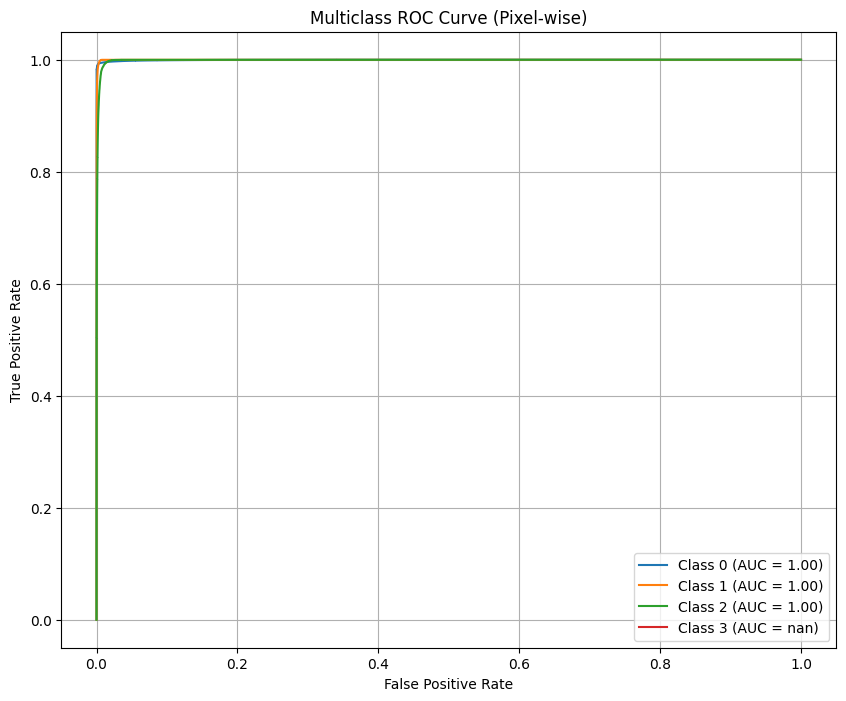

In [14]:
plot_multiclass_roc(model, val_loader, num_classes=4, device=device)

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(val_loader, num_classes=4, device='cuda'):
    pixel_counts = np.zeros(num_classes, dtype=np.int64)

    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch  # assuming (B, H, W) or (B, 1, H, W)
            masks = masks.to(device)

            # If masks have a channel dimension (B, 1, H, W), squeeze it
            if masks.ndim == 4:
                masks = masks.squeeze(1)

            for c in range(num_classes):
                pixel_counts[c] += (masks == c).sum().item()

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.bar(range(num_classes), pixel_counts, color='skyblue')
    plt.xticks(range(num_classes), [f'Class {i}' for i in range(num_classes)])
    plt.xlabel('Class')
    plt.ylabel('Pixel Count')
    plt.title('Pixel Count per Class in Validation Set')
    plt.grid(axis='y')
    plt.show()

    return pixel_counts


✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_654_1\BraTS19_TCIA13_654_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_654_1\BraTS19_TCIA13_654_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_654_1\BraTS19_TCIA13_654_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_654_1\BraTS19_TCIA13_654_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA13_654_1\BraTS19_TCIA13_654_1_seg.nii
✅ Loaded BraTS19_TCIA13_

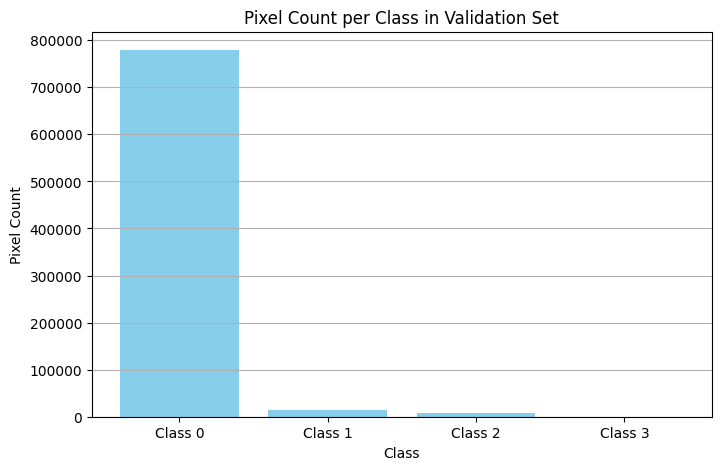

array([779117,  14909,   7850,      0])

In [9]:
plot_class_distribution(val_loader, num_classes=4, device=device)


In [16]:
import torch

def compute_iou(preds, labels, num_classes=4, smooth=1e-6):
    """
    Compute per-class IoU and mean IoU.

    Args:
        preds (Tensor): [B, H, W] predicted class indices
        labels (Tensor): [B, H, W] ground truth class indices
        num_classes (int): number of segmentation classes
        smooth (float): smoothing to avoid division by zero

    Returns:
        iou_per_class (list): IoU for each class
        mean_iou (float): average IoU across all classes
    """
    iou_per_class = []

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (labels == cls)
        
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        iou = (intersection + smooth) / (union + smooth)
        iou_per_class.append(iou.item())
    
    mean_iou = sum(iou_per_class) / num_classes
    return iou_per_class, mean_iou

In [21]:
model1.eval()
total_iou = torch.zeros(4)
num_batches = 0

with torch.no_grad():
    for batch in val_loader:
        images, masks = batch  # Unpack the tuple
        images = images.to(device)
        masks = masks.to(device)

        outputs = model1(images)
        outputs = outputs[0]              # [B, num_classes, H, W]
        preds = torch.argmax(outputs, dim=1)    # [B, H, W]

        preds = preds.unsqueeze(1).float()
        preds = F.interpolate(preds, size=masks.shape[1:], mode='nearest')
        preds = preds.squeeze(1).long()

        iou_per_class, mean_iou = compute_iou(preds, masks, num_classes=4)
        total_iou += torch.tensor(iou_per_class)
        num_batches += 1

avg_iou_per_class = total_iou / num_batches
mean_iou = avg_iou_per_class.mean()

print("✅ Average IoU per class:", avg_iou_per_class.tolist())
print("✅ Mean IoU across all classes:", mean_iou.item())

✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_seg.nii
✅ Loaded BraTS19_TCIA12_

In [19]:
outputs = model1(images)
print(type(outputs))
print(len(outputs) if isinstance(outputs, tuple) else "Not a tuple")

<class 'tuple'>
3


In [14]:
print("preds shape:", preds.shape)
print("masks shape:", masks.shape)

NameError: name 'preds' is not defined

In [25]:
import torch
import numpy as np
from medpy.metric.binary import hd95

def sensitivity(preds, labels, class_idx):
    """
    Sensitivity for a given class.
    preds, labels: torch tensors, shape [B, H, W]
    """
    preds = (preds == class_idx).cpu().numpy()
    labels = (labels == class_idx).cpu().numpy()

    TP = np.logical_and(preds, labels).sum()
    FN = np.logical_and(np.logical_not(preds), labels).sum()

    sens = TP / (TP + FN + 1e-6)
    return sens

def specificity(preds, labels, class_idx):
    """
    Specificity for a given class.
    preds, labels: torch tensors, shape [B, H, W]
    """
    preds = (preds == class_idx).cpu().numpy()
    labels = (labels == class_idx).cpu().numpy()

    TN = np.logical_and(np.logical_not(preds), np.logical_not(labels)).sum()
    FP = np.logical_and(preds, np.logical_not(labels)).sum()

    spec = TN / (TN + FP + 1e-6)
    return spec

def hd95_metric(preds, labels, class_idx):
    """
    HD95 for a given class.
    preds, labels: torch tensors, shape [B, H, W]
    """
    preds = (preds == class_idx).cpu().numpy()
    labels = (labels == class_idx).cpu().numpy()

    batch_hd95 = []
    for i in range(preds.shape[0]):
        p = preds[i].astype(np.uint8)
        l = labels[i].astype(np.uint8)
        # Handle empty masks (no positives)
        if p.sum() == 0 and l.sum() == 0:
            batch_hd95.append(0.0)
        elif p.sum() == 0 or l.sum() == 0:
            batch_hd95.append(np.nan)  # or some large number
        else:
            batch_hd95.append(hd95(p, l))
    # Return average ignoring NaNs
    batch_hd95 = np.array(batch_hd95)
    return np.nanmean(batch_hd95)

# Example usage in validation loop

num_classes = 4
total_sensitivity = np.zeros(num_classes)
total_specificity = np.zeros(num_classes)
total_hd95 = np.zeros(num_classes)
num_batches = 0

model1.eval()
with torch.no_grad():
    for batch in val_loader:
        images = batch[0].to(device)
        masks = batch[1].to(device)
        outputs = model1(images)[0]
        preds = torch.argmax(outputs, dim=1)

        preds_resized = F.interpolate(preds.unsqueeze(1).float(), size=masks.shape[1:], mode='nearest').squeeze(1).long()

        for c in range(num_classes):
            total_sensitivity[c] += sensitivity(preds_resized, masks, c)
            total_specificity[c] += specificity(preds_resized, masks, c)
            total_hd95[c] += hd95_metric(preds_resized, masks, c)
        num_batches += 1

avg_sensitivity = total_sensitivity / num_batches
avg_specificity = total_specificity / num_batches
avg_hd95 = total_hd95 / num_batches

print("Sensitivity per class:", avg_sensitivity)
print("Specificity per class:", avg_specificity)
print("HD95 per class:", avg_hd95)

✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_seg.nii
✅ Loaded BraTS19_TCIA12_

In [31]:
from torch.utils.data import Dataset

class RemoveT2Wrapper(Dataset):
    def __init__(self, original_dataset):
        self.dataset = original_dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        # Assuming sample is a dict or tuple with 'image' and 'mask'
        # Adjust according to your dataset structure

        # If dict:
        # image shape: [4, H, W]
        image = sample[0]  # tensor [4, H, W]
        mask = sample[1]    # tensor [H, W]

        # Remove T2 (4th channel, index 3)
        image_3ch = torch.cat([image[:3]], dim=0)  # or simply image[:3, :, :]

        # Return modified sample (keep mask same)
        return {'image': image_3ch, 'mask': mask}

In [36]:
import torch
import torch.nn.functional as F

def dice_score(preds, targets, num_classes=4, smooth=1e-6):
    dice_per_class = []
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2 * intersection + smooth) / (union + smooth)
        dice_per_class.append(dice.item())
    return dice_per_class


def evaluate_model(model, val_loader, device, num_classes=4):
    model.eval()
    total_dice = torch.zeros(num_classes).to(device)
    total_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)

            outputs = model(images)
            main_pred = outputs[0]  # Only use main prediction

            # Resize output to match mask size if necessary
            main_pred = F.interpolate(main_pred, size=masks.shape[1:], mode="bilinear", align_corners=False)

            preds = torch.argmax(main_pred, dim=1)

            batch_dice = dice_score(preds, masks, num_classes=num_classes)
            total_dice += torch.tensor(batch_dice, device=device)
            total_batches += 1

    avg_dice = total_dice / total_batches

    for cls, score in enumerate(avg_dice):
        print(f"🔹 Dice Score for Class {cls}: {score:.4f}")
    print(f"\n🎯 Mean Dice Score: {avg_dice.mean():.4f}")

In [33]:
val_dataset_no_t2 = RemoveT2Wrapper(val_dataset)
val_loader_no_t2 = DataLoader(val_dataset_no_t2, batch_size=2, shuffle=False, num_workers=0)

In [37]:
evaluate_model(model1, val_loader_no_t2, device)

✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_flair.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t1.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t1ce.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_t2.nii
✅ Loading: C:\Users\Dell\.cache\kagglehub\datasets\aryashah2k\brain-tumor-segmentation-brats-2019\versions\1\MICCAI_BraTS_2019_Data_Training\LGG\BraTS19_TCIA12_101_1\BraTS19_TCIA12_101_1_seg.nii
✅ Loaded BraTS19_TCIA12_

RuntimeError: Given groups=1, weight of size [96, 4, 4, 4], expected input[2, 3, 224, 224] to have 4 channels, but got 3 channels instead